# Predictia accidentelor rutiere - problema de clasificare

Acest notebook prezinta rezolvarea unei probleme de clasificare binara folosind un dataset despre accidente rutiere.

Scopul este de a construi, compara si interpreta mai multe modele de machine learning care pot prezice daca are loc sau nu un accident.

# 1. Definirea problemei

Problema analizata este una de clasificare binara.

Scopul este sa prezicem variabila `Accident`, care indica daca s-a produs sau nu un accident rutier.

Variabila tinta:
- `Accident`

Clasele existente sunt:
- `0` - nu s-a produs accident
- `1` - s-a produs accident

Variabilele de intrare descriu factori precum:
- conditiile meteo
- tipul drumului
- momentul zilei
- densitatea traficului
- limita de viteza
- numarul de vehicule
- consumul de alcool
- starea drumului
- tipul vehiculului
- varsta si experienta soferului
- conditiile de iluminare

Aceasta problema este relevanta deoarece predictia riscului de accident poate fi utila pentru siguranta rutiera si pentru analiza factorilor care pot contribui la aparitia accidentelor.

Am ales aceasta tema deoarece este o problema usor de inteles, cu aplicabilitate reala, iar variabilele din dataset permit o analiza clara si interpretabila.


# 2. Incarcarea bibliotecilor si a dataset-ului

In aceasta etapa importam bibliotecile necesare si incarcam dataset-ul.

Vom folosi:
- `pandas` si `numpy` pentru manipularea datelor
- `matplotlib` si `seaborn` pentru vizualizari
- `scikit-learn` pentru modelele de machine learning
- `SHAP` pentru explicabilitatea modelelor


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../CSV_data/dataset_traffic_accident_prediction.csv")

df.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [4]:
df.shape

(840, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               798 non-null    str    
 1   Road_Type             798 non-null    str    
 2   Time_of_Day           798 non-null    str    
 3   Traffic_Density       798 non-null    float64
 4   Speed_Limit           798 non-null    float64
 5   Number_of_Vehicles    798 non-null    float64
 6   Driver_Alcohol        798 non-null    float64
 7   Accident_Severity     798 non-null    str    
 8   Road_Condition        798 non-null    str    
 9   Vehicle_Type          798 non-null    str    
 10  Driver_Age            798 non-null    float64
 11  Driver_Experience     798 non-null    float64
 12  Road_Light_Condition  798 non-null    str    
 13  Accident              798 non-null    float64
dtypes: float64(7), str(7)
memory usage: 128.7 KB


In [6]:
df.isnull().sum()

Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density         42
Speed_Limit             42
Number_of_Vehicles      42
Driver_Alcohol          42
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age              42
Driver_Experience       42
Road_Light_Condition    42
Accident                42
dtype: int64

In [7]:
df["Accident"].value_counts(dropna=False)

Accident
0.0    559
1.0    239
NaN     42
Name: count, dtype: int64

In [8]:
df.describe()

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
count,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000
mean,1.001253,71.050125,3.286967,0.160401,43.259398,38.981203,0.299499
std,0.784894,32.052458,2.017267,0.367208,15.129856,15.273201,0.458326
min,0.000000,30.000000,1.000000,0.000000,18.000000,9.000000,0.000000
25%,0.000000,50.000000,2.000000,0.000000,30.000000,26.000000,0.000000
50%,1.000000,60.000000,3.000000,0.000000,43.000000,39.000000,0.000000
75%,2.000000,80.000000,4.000000,0.000000,56.000000,52.750000,1.000000
max,2.000000,213.000000,14.000000,1.000000,69.000000,69.000000,1.000000


## Observatii initiale asupra dataset-ului

Dataset-ul contine informatii despre conditii de drum, trafic, vreme si caracteristici ale soferului.

Variabila tinta este `Accident`, care indica daca s-a produs un accident.

Se observa ca exista valori lipsa in dataset, iar acestea trebuie tratate in etapa de preprocesare.

De asemenea, coloana `Accident_Severity` nu va fi folosita ca variabila de intrare, deoarece poate introduce data leakage. Aceasta coloana descrie severitatea accidentului si este cunoscuta doar dupa producerea acestuia.

In plus, variabila tinta este usor dezechilibrata, deoarece exista mai multe cazuri fara accident decat cazuri cu accident. Acest lucru trebuie luat in calcul la evaluarea modelelor.


# 3. Analiza exploratorie a datelor si pregatirea lor

In aceasta etapa realizam analiza exploratorie a datelor.

Scopul este intelegerea:
- distributiei variabilei tinta
- distributiei variabilelor numerice
- posibilelor valori extreme
- relatiei dintre variabile si target
- comportamentului variabilelor categorice


## 3.1 Distributia variabilei tinta

Analizam distributia variabilei `Accident` pentru a vedea cate exemple apartin fiecarei clase.


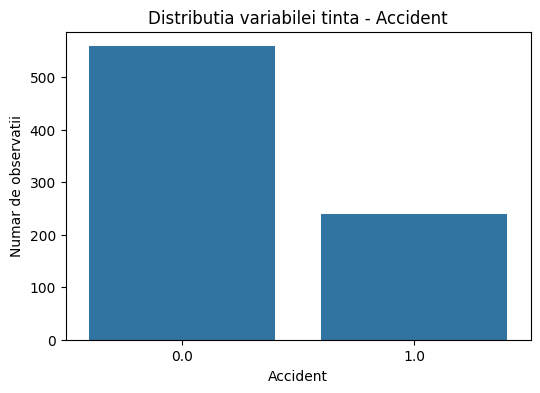

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Accident", data=df)
plt.title("Distributia variabilei tinta - Accident")
plt.xlabel("Accident")
plt.ylabel("Numar de observatii")
plt.show()

Se observa ca majoritatea cazurilor sunt din clasa `0`, adica situatii in care nu s-a produs accident.

Clasa `1`, adica situatiile in care s-a produs accident, este mai putin frecventa.

Aceasta diferenta indica un dezechilibru al claselor, motiv pentru care metrici precum precision, recall si F1-score sunt mai relevante decat accuracy simplu.


## 3.2 Distributia variabilelor numerice

Analizam distributiile variabilelor numerice pentru a intelege intervalele de valori si posibilele valori extreme.


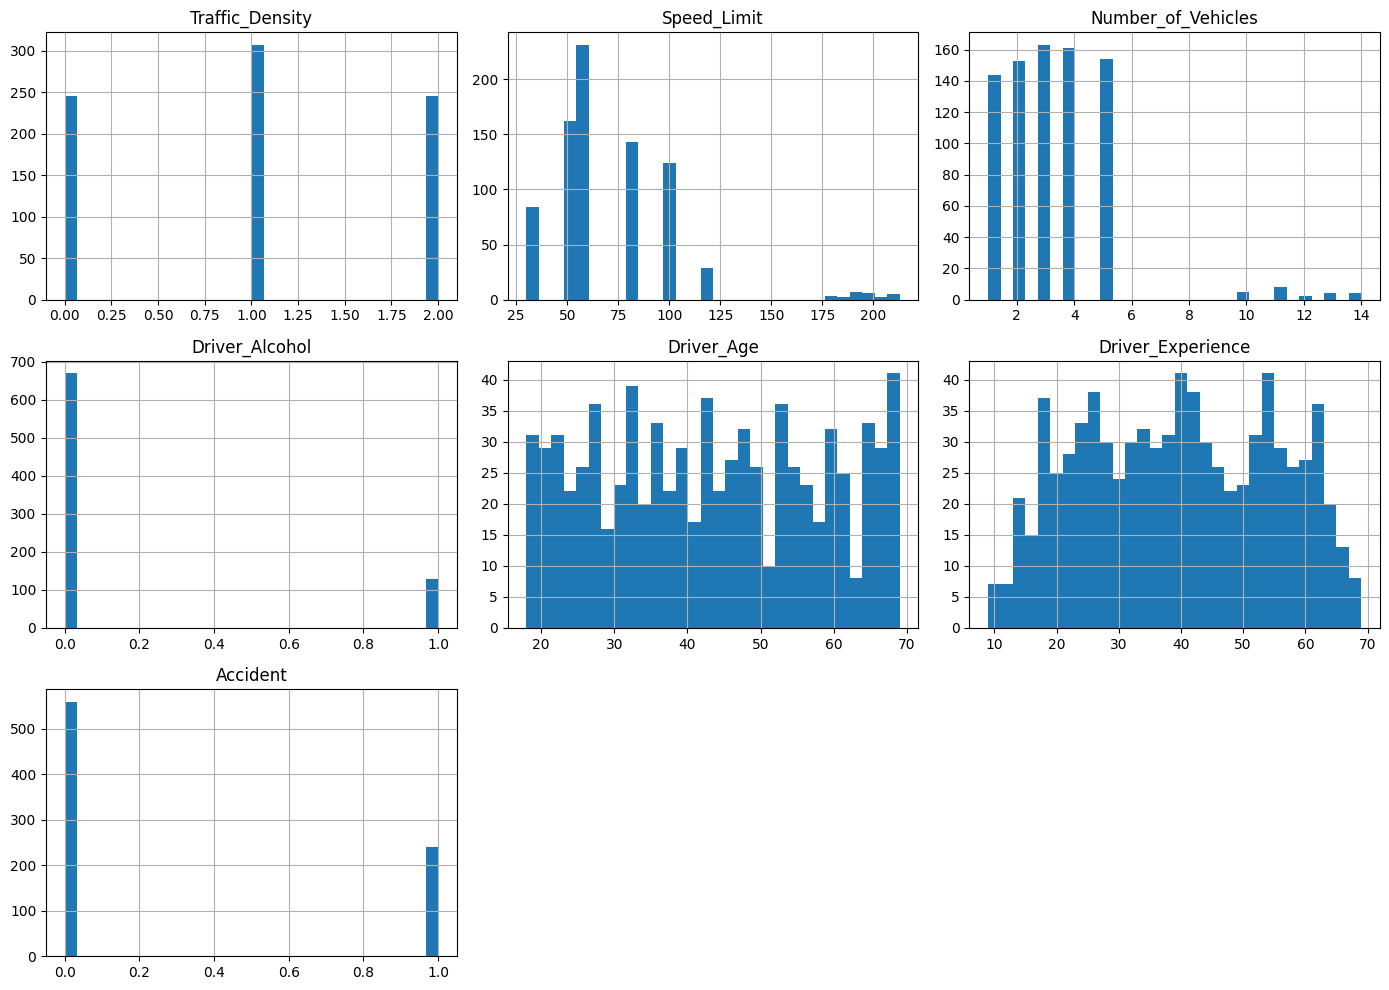

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

Variabilele numerice au distributii diferite.

Se observa ca `Driver_Alcohol` are in principal valori 0, ceea ce arata ca majoritatea soferilor nu consumasera alcool.

Variabile precum `Speed_Limit`, `Number_of_Vehicles`, `Driver_Age` si `Driver_Experience` pot contribui la predictia accidentelor.

De asemenea, pot exista valori extreme, de exemplu la `Speed_Limit`, care trebuie analizate in context.


## 3.3 Analiza valorilor extreme

Pentru a observa posibile valori extreme, folosim boxplot-uri pentru variabilele numerice principale.


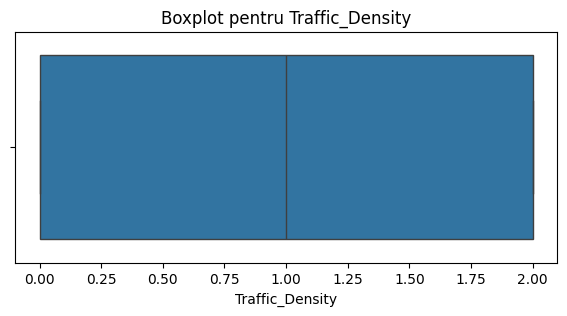

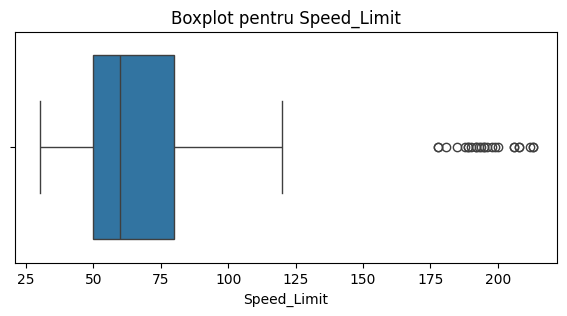

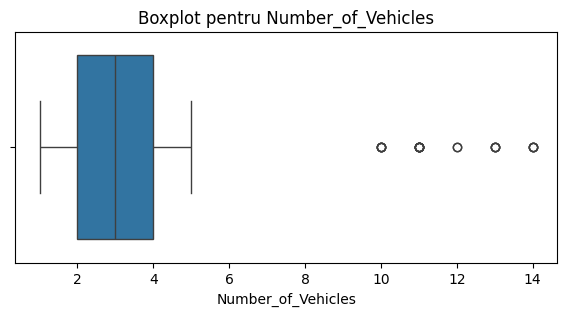

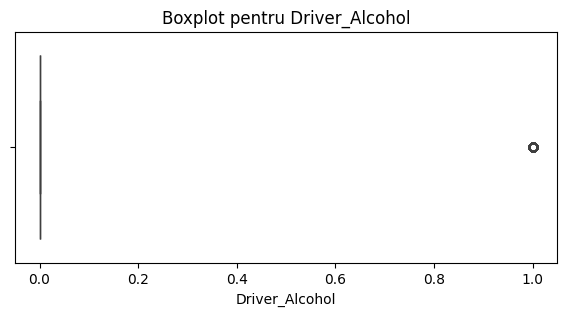

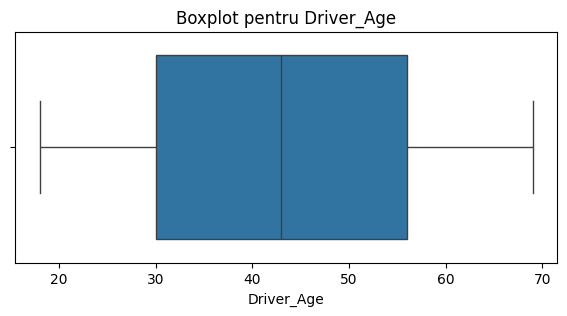

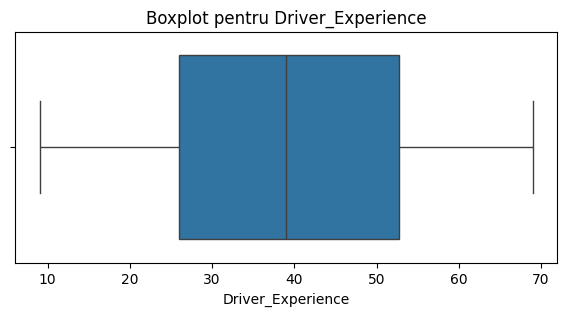

In [11]:
numeric_features = [
    "Traffic_Density", "Speed_Limit", "Number_of_Vehicles",
    "Driver_Alcohol", "Driver_Age", "Driver_Experience"
]

for col in numeric_features:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot pentru {col}")
    plt.show()

Boxplot-urile ajuta la identificarea valorilor aflate departe de majoritatea datelor.

In cazul accidentelor rutiere, valorile extreme nu trebuie eliminate automat, deoarece pot reprezenta situatii reale, cum ar fi limite de viteza foarte mari sau un numar mare de vehicule implicate.

Aceste observatii sunt utile pentru intelegerea dataset-ului inainte de modelare.


## 3.4 Matricea de corelatie

Matricea de corelatie arata relatiile liniare dintre variabilele numerice.

Ne intereseaza in special relatia dintre variabilele numerice si target-ul `Accident`.


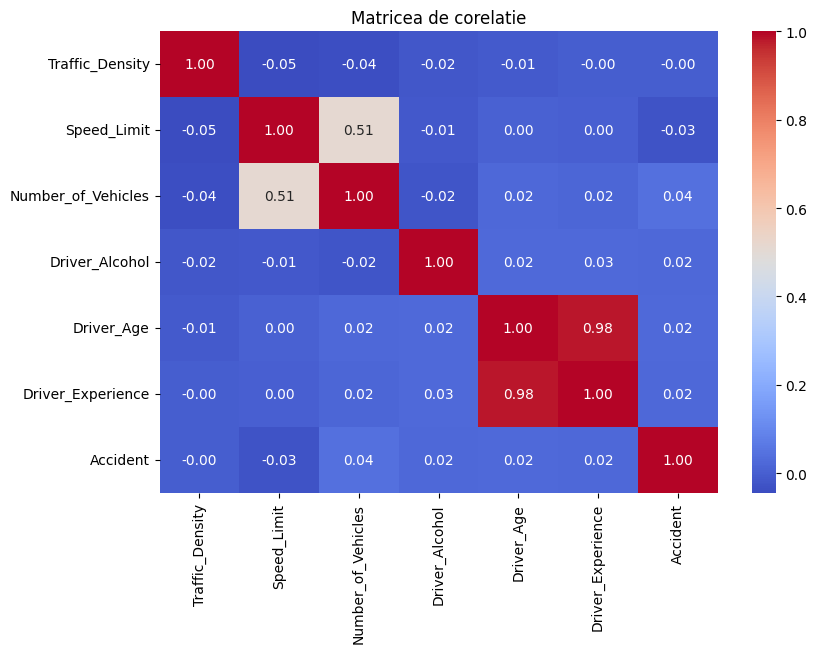

In [12]:
plt.figure(figsize=(9,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matricea de corelatie")
plt.show()

Corelatiile dintre variabile sunt in general moderate sau slabe.

Acest lucru nu inseamna ca variabilele nu sunt utile, deoarece modelele de machine learning pot surprinde relatii mai complexe decat relatiile liniare simple.

Totusi, matricea de corelatie este utila pentru a observa eventuale relatii intre variabile.


## 3.5 Relatia dintre variabile numerice si target

Analizam cateva variabile numerice in raport cu target-ul `Accident`.


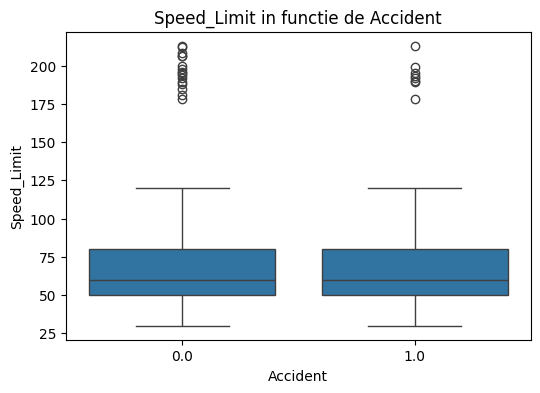

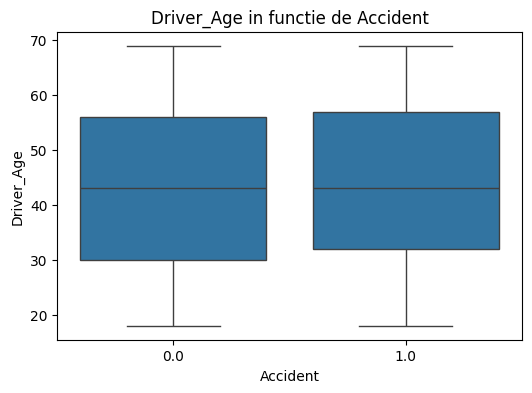

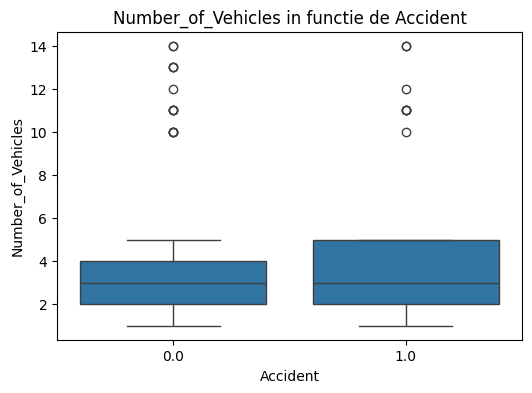

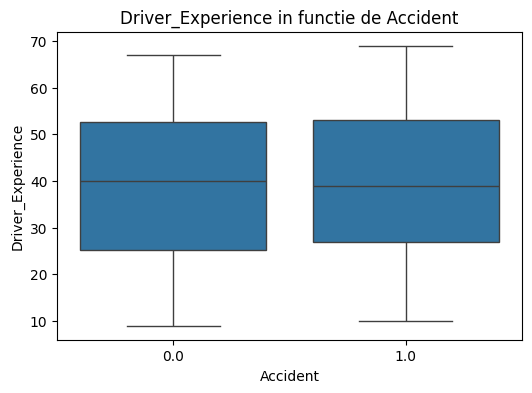

In [13]:
for col in ["Speed_Limit", "Driver_Age", "Number_of_Vehicles", "Driver_Experience"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Accident", y=col, data=df)
    plt.title(f"{col} in functie de Accident")
    plt.show()

Graficele permit compararea distributiei variabilelor numerice pentru cele doua clase ale target-ului.

Daca distributiile difera intre clasa 0 si clasa 1, atunci variabila respectiva poate fi utila pentru model.

De exemplu, viteza, numarul de vehicule sau experienta soferului pot influenta probabilitatea aparitiei unui accident.


## 3.6 Analiza variabilelor categorice

Analizam distributia variabilelor categorice, precum vremea, tipul drumului si momentul zilei.


C:\Users\stanu\AppData\Local\Temp\ipykernel_17340\1650957348.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


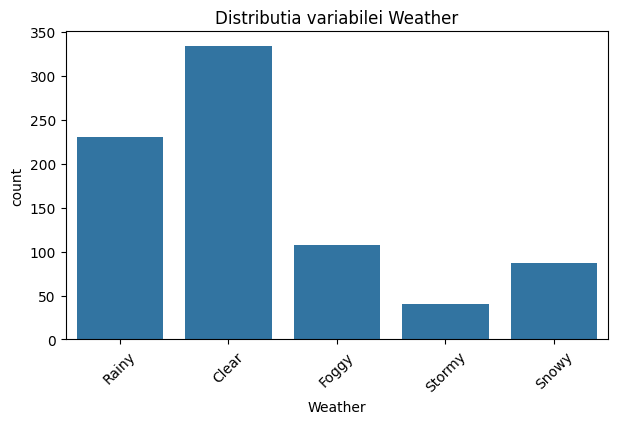

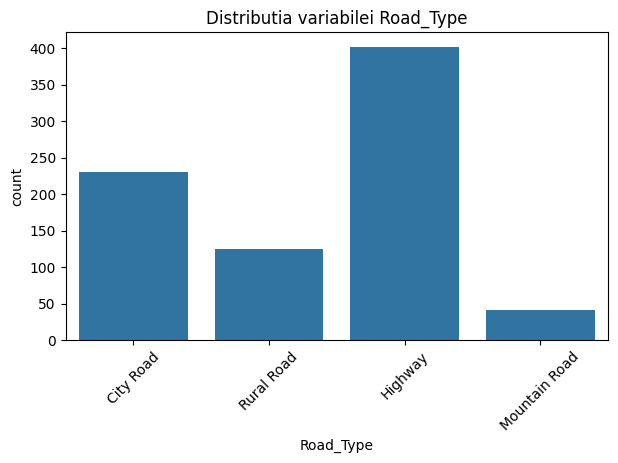

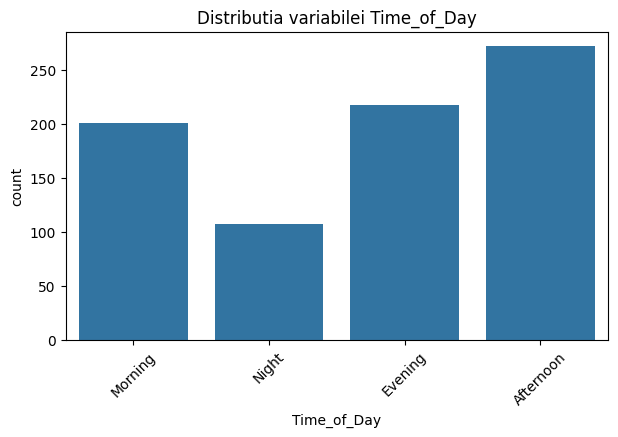

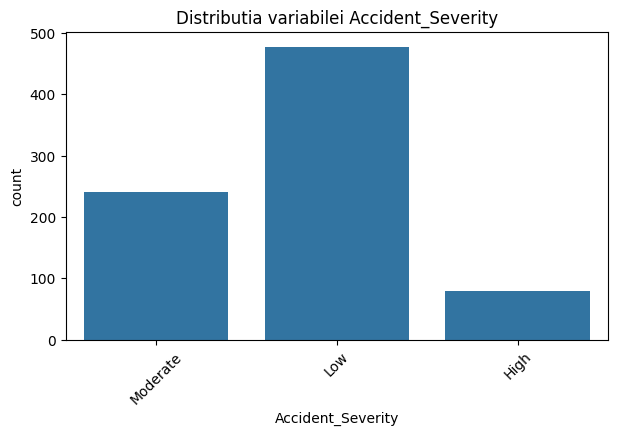

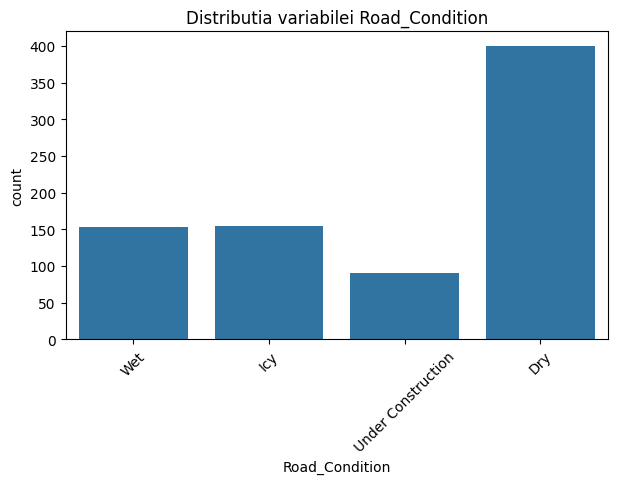

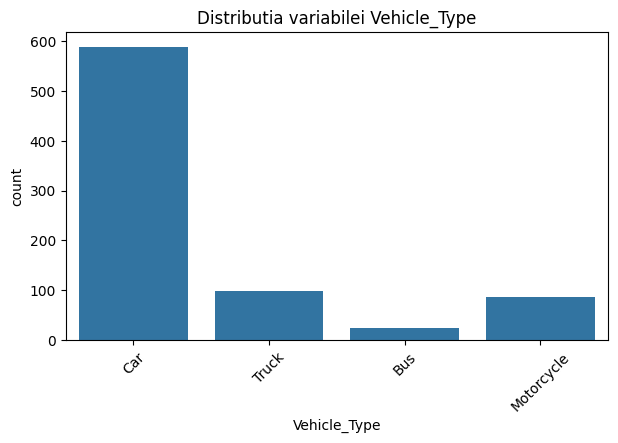

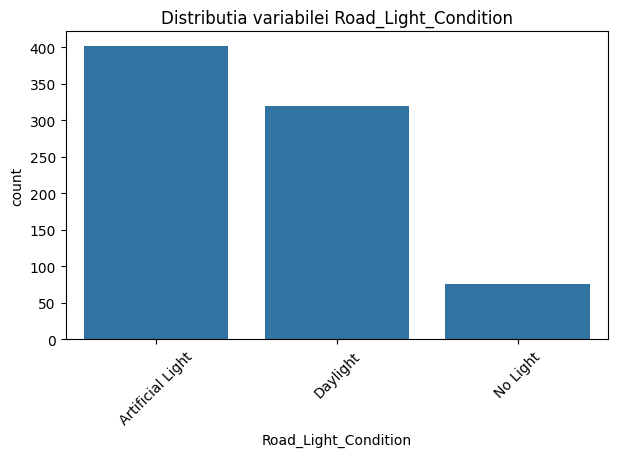

In [14]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distributia variabilei {col}")
    plt.show()

Variabilele categorice ofera informatii importante despre contextul accidentelor.

Conditii precum vremea, tipul drumului, starea drumului si iluminarea pot influenta riscul producerii unui accident.


## 3.7 Relatia dintre variabile categorice si target

Analizam cum se distribuie clasele target in functie de variabilele categorice.


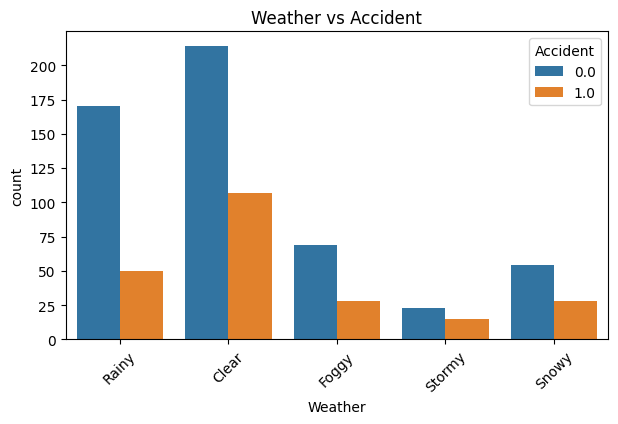

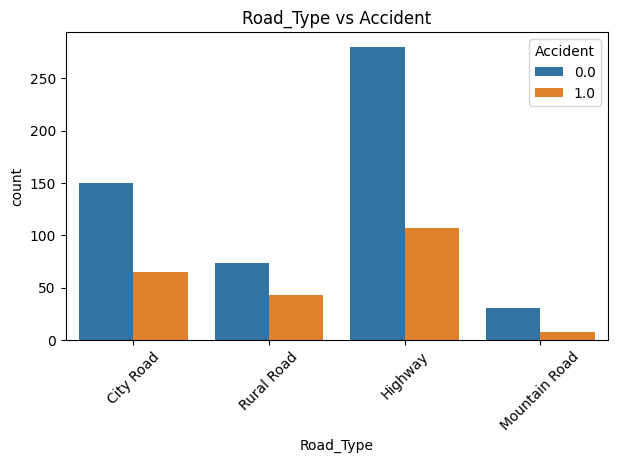

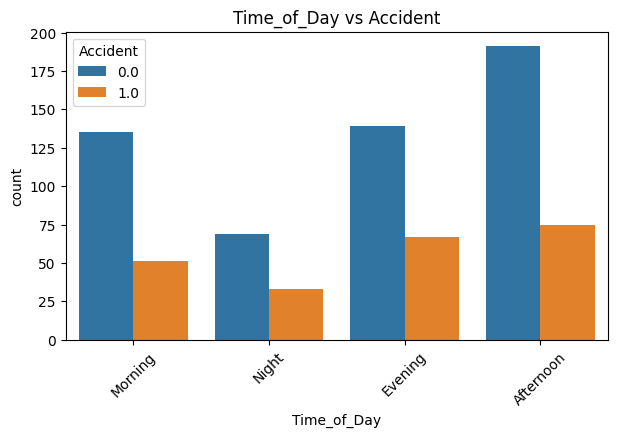

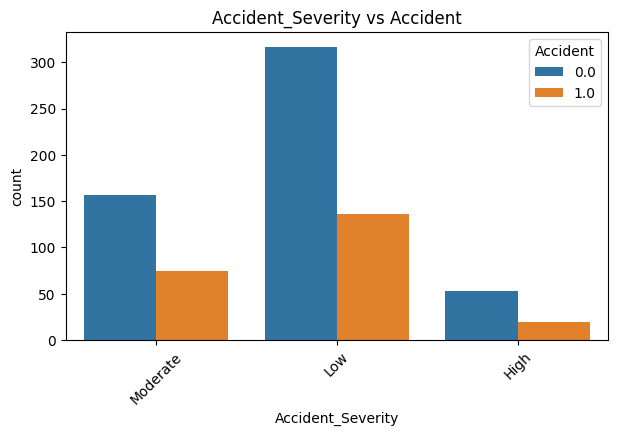

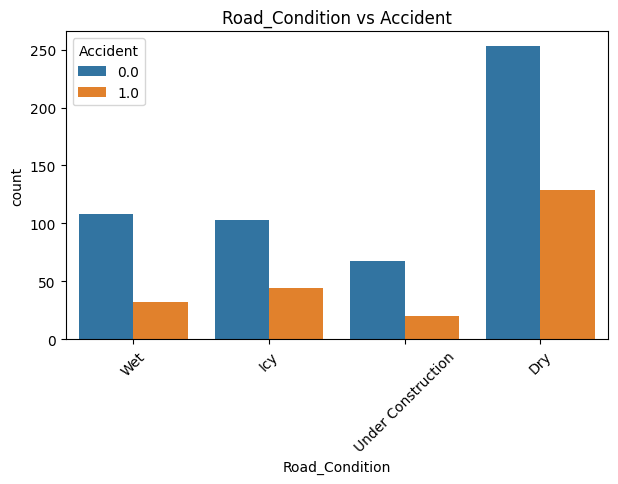

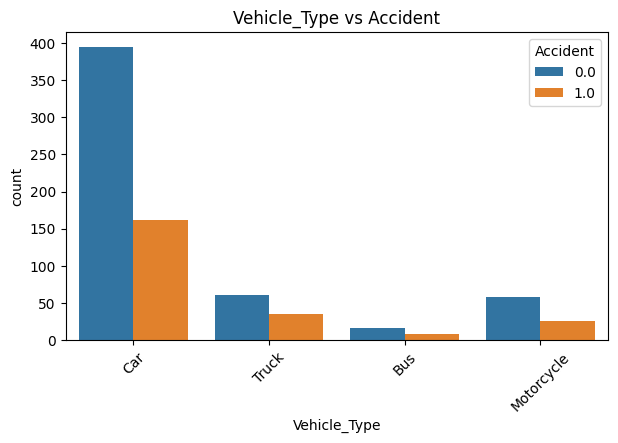

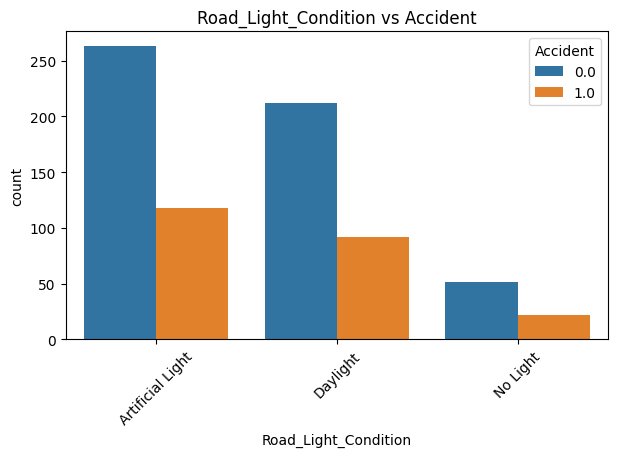

In [15]:
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue="Accident", data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Accident")
    plt.show()

Aceste grafice ajuta la observarea relatiilor dintre variabilele categorice si aparitia accidentelor.

De exemplu, anumite conditii meteo, tipuri de drum sau conditii de iluminare pot fi asociate cu o frecventa mai mare a accidentelor.

Aceste variabile vor fi transformate numeric in etapa de preprocesare pentru a putea fi folosite de modele.


# 4. Preprocesarea datelor

In aceasta etapa pregatim datele pentru modelele de machine learning.

Sunt realizate urmatoarele operatii:
- eliminarea valorilor lipsa
- eliminarea coloanei `Accident_Severity` pentru a evita data leakage
- conversia target-ului in format numeric intreg
- transformarea variabilelor categorice prin One-Hot Encoding
- impartirea datelor in train si test


## 4.1 Eliminarea valorilor lipsa si a coloanei problematice

Eliminam randurile cu valori lipsa deoarece numarul lor este redus fata de dimensiunea dataset-ului.

Eliminam `Accident_Severity`, deoarece aceasta poate introduce data leakage.


In [16]:
df_clean = df.dropna().copy()

df_clean = df_clean.drop("Accident_Severity", axis=1)

df_clean["Accident"] = df_clean["Accident"].astype(int)

df_clean.shape

(405, 13)

## 4.2 Separarea variabilelor de intrare si a target-ului

Separaram dataset-ul in:
- `X`: variabilele de intrare
- `y`: variabila tinta


In [17]:
X = df_clean.drop("Accident", axis=1)
y = df_clean["Accident"]

X.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Icy,Car,54.0,52.0,Artificial Light
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Under Construction,Bus,34.0,31.0,Daylight
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Dry,Car,62.0,55.0,Artificial Light
6,Foggy,Highway,Afternoon,0.0,60.0,4.0,0.0,Dry,Truck,27.0,26.0,Daylight
7,Rainy,City Road,Afternoon,0.0,60.0,4.0,0.0,Dry,Car,29.0,22.0,Artificial Light


In [18]:
y.head()

2    0
3    0
4    1
6    1
7    1
Name: Accident, dtype: int64

## 4.3 One-Hot Encoding pentru variabile categorice

Modelele de machine learning nu pot lucra direct cu texte, deci variabilele categorice sunt transformate numeric folosind One-Hot Encoding.


In [19]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Stormy,Road_Type_Highway,Road_Type_Mountain Road,Road_Type_Rural Road,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Road_Condition_Icy,Road_Condition_Under Construction,Road_Condition_Wet,Vehicle_Type_Car,Vehicle_Type_Motorcycle,Vehicle_Type_Truck,Road_Light_Condition_Daylight,Road_Light_Condition_No Light
2,1.0,60.0,4.0,0.0,54.0,52.0,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False
3,2.0,60.0,3.0,0.0,34.0,31.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
4,1.0,195.0,11.0,0.0,62.0,55.0,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False
6,0.0,60.0,4.0,0.0,27.0,26.0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False
7,0.0,60.0,4.0,0.0,29.0,22.0,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


## 4.4 Impartirea datelor in train si test

Datele sunt impartite in:
- 75% pentru antrenare
- 25% pentru testare

Folosim `stratify=y` pentru a pastra proportia claselor in ambele seturi.


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((303, 24), (102, 24))

# 5. Antrenarea si compararea modelelor de baza

In aceasta etapa antrenam mai multe modele de clasificare si comparam performanta acestora.

Modelele folosite sunt:
- Naive Bayes
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine
- K-Nearest Neighbors
- XGBoost, CatBoost si Explainable Boosting Machine, daca librariile sunt disponibile

Metricile folosite sunt:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Deoarece dataset-ul este dezechilibrat, F1-score si Recall sunt foarte importante.


## 5.1 Importarea modelelor si metricilor

Importam modelele si metricile necesare pentru evaluarea clasificarii.


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

## 5.2 Functie de evaluare

Cream o functie care calculeaza automat metricile pentru fiecare model.

Aceasta functie ajuta la compararea rapida a modelelor.


In [22]:
def evaluate_classification_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    roc_auc = np.nan
    try:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_score)
    except Exception:
        pass

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

## 5.3 Definirea modelelor de baza

Definim modelele care vor fi antrenate.

Pentru Logistic Regression, SVM si KNN folosim StandardScaler, deoarece aceste modele sunt sensibile la scala valorilor.

Pentru unele modele folosim `class_weight="balanced"`, deoarece dataset-ul este dezechilibrat si dorim sa imbunatatim detectarea accidentelor.


In [23]:
models = {
    "Naive Bayes": GaussianNB(),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight="balanced"
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(class_weight="balanced", probability=True))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}

## 5.4 Modele optionale: XGBoost, CatBoost si EBM

Pentru a respecta cat mai bine lista de algoritmi propusi, incercam sa adaugam si modele mai avansate.

In [24]:
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
except Exception:
    print("XGBoost nu este instalat.")

try:
    from catboost import CatBoostClassifier
    models["CatBoost"] = CatBoostClassifier(
        random_state=42,
        verbose=0
    )
except Exception:
    print("CatBoost nu este instalat.")

try:
    from interpret.glassbox import ExplainableBoostingClassifier
    models["EBM"] = ExplainableBoostingClassifier(random_state=42)
except Exception:
    print("Interpret / EBM nu este instalat.")

## 5.5 Antrenarea modelelor de baza

Antrenam fiecare model pe setul de antrenare si il evaluam pe setul de test.


In [25]:
base_results = []

for name, model in models.items():
    print(f"Antrenare model: {name}")
    model.fit(X_train, y_train)

    metrics = evaluate_classification_model(model, X_test, y_test)
    metrics["Model"] = name
    base_results.append(metrics)

base_results_df = pd.DataFrame(base_results)
base_results_df = base_results_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]
base_results_df.sort_values(by="F1", ascending=False)

Antrenare model: Naive Bayes
Antrenare model: Logistic Regression
Antrenare model: Decision Tree
Antrenare model: Random Forest
Antrenare model: SVM
Antrenare model: KNN
Antrenare model: XGBoost
Antrenare model: CatBoost
Antrenare model: EBM


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Decision Tree,0.666667,0.428571,0.400000,0.413793,0.588889
1,Logistic Regression,0.480392,0.274510,0.466667,0.345679,0.494907
6,XGBoost,0.696078,0.470588,0.266667,0.340426,0.563889
0,Naive Bayes,0.568627,0.294118,0.333333,0.312500,0.499537
4,SVM,0.549020,0.264706,0.300000,0.281250,0.475463
3,Random Forest,0.705882,0.500000,0.166667,0.250000,0.624537
5,KNN,0.647059,0.333333,0.200000,0.250000,0.506713
8,EBM,0.715686,0.666667,0.066667,0.121212,0.559722
7,CatBoost,0.696078,0.400000,0.066667,0.114286,0.561111


## 5.6 Interpretarea rezultatelor modelelor de baza

Modelele sunt comparate in functie de mai multe metrici.

`Accuracy` arata proportia predictiilor corecte, dar poate fi inselatoare atunci cand clasele sunt dezechilibrate.

`Recall` este important deoarece arata cate accidente reale au fost detectate corect.

`Precision` arata cate dintre predictiile de accident au fost corecte.

`F1-score` combina precision si recall, fiind o metrica potrivita pentru aceasta problema.

`ROC-AUC` arata capacitatea modelului de a separa cele doua clase.


# 6. Selectarea celor mai bune 5 modele

In aceasta etapa alegem primele 5 modele in functie de F1-score.

F1-score este ales deoarece ofera un echilibru intre precision si recall.

Pentru aceasta problema, este important ca modelul sa detecteze accidentele, nu doar sa obtina o acuratete mare.


In [26]:
top5_models_df = base_results_df.sort_values(by="F1", ascending=False).head(5)

top5_models_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Decision Tree,0.666667,0.428571,0.400000,0.413793,0.588889
1,Logistic Regression,0.480392,0.274510,0.466667,0.345679,0.494907
6,XGBoost,0.696078,0.470588,0.266667,0.340426,0.563889
0,Naive Bayes,0.568627,0.294118,0.333333,0.312500,0.499537
4,SVM,0.549020,0.264706,0.300000,0.281250,0.475463


Modelele din top 5 vor fi folosite in etapa urmatoare pentru ajustarea hiperparametrilor.

Aceasta selectie este necesara deoarece nu este eficient sa optimizam toate modelele, ci doar pe cele mai promitatoare.


# 7. Ajustarea hiperparametrilor

In aceasta etapa folosim GridSearchCV pentru optimizarea celor mai bune modele.

Scopul este sa gasim combinatii mai bune de hiperparametri pentru a imbunatati performanta.

Metrica folosita este F1-score, deoarece este potrivita pentru clasificare dezechilibrata.


## 7.1 Definirea grilelor de hiperparametri

Pentru fiecare model important definim o grila de valori care vor fi testate de GridSearchCV.


In [27]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Naive Bayes": {
        "var_smoothing": [1e-9, 1e-8, 1e-7]
    },

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["liblinear", "lbfgs"]
    },

    "Decision Tree": {
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9],
        "model__weights": ["uniform", "distance"]
    }
}

if "XGBoost" in models:
    param_grids["XGBoost"] = {
        "n_estimators": [50, 100],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1]
    }

if "CatBoost" in models:
    param_grids["CatBoost"] = {
        "iterations": [100, 200],
        "depth": [4, 6],
        "learning_rate": [0.05, 0.1]
    }

if "EBM" in models:
    param_grids["EBM"] = {
        "max_bins": [128],
        "learning_rate": [0.05],
        "max_rounds": [500]
    }

## 7.2 Aplicarea GridSearchCV pe top 5 modele

Optimizam doar modelele aflate in top 5 dupa F1-score.


In [28]:
top5_names = top5_models_df["Model"].tolist()

tuned_models = {}
tuned_cv_results = []

for name in top5_names:
    print(f"Optimizez modelul: {name}")

    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    tuned_models[f"Tuned {name}"] = grid.best_estimator_
    tuned_cv_results.append({
        "Model": f"Tuned {name}",
        "Best Params": grid.best_params_,
        "Best CV F1": grid.best_score_
    })

pd.DataFrame(tuned_cv_results)

Optimizez modelul: Decision Tree
Optimizez modelul: Logistic Regression
Optimizez modelul: XGBoost
Optimizez modelul: Naive Bayes
Optimizez modelul: SVM


,Model,Best Params,Best CV F1
0,Tuned Decision Tree,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.370498
1,Tuned Logistic Regression,"{'model__C': 0.01, 'model__solver': 'liblinear'}",0.384301
2,Tuned XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.307502
3,Tuned Naive Bayes,{'var_smoothing': 1e-09},0.303473
4,Tuned SVM,"{'model__C': 10, 'model__kernel': 'linear'}",0.350826


# 8. Compararea modelelor optimizate

Dupa ajustarea hiperparametrilor, modelele optimizate sunt evaluate din nou pe setul de test.

Scopul este sa observam daca tuning-ul a imbunatatit performanta fata de modelele de baza.


In [29]:
tuned_results = []

for name, model in tuned_models.items():
    metrics = evaluate_classification_model(model, X_test, y_test)
    metrics["Model"] = name
    tuned_results.append(metrics)

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]
tuned_results_df.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Tuned Logistic Regression,0.480392,0.283019,0.500000,0.361446,0.500463
2,Tuned XGBoost,0.715686,0.533333,0.266667,0.355556,0.600926
4,Tuned SVM,0.460784,0.254902,0.433333,0.320988,0.473611
3,Tuned Naive Bayes,0.568627,0.294118,0.333333,0.312500,0.499537
0,Tuned Decision Tree,0.519608,0.268293,0.366667,0.309859,0.492824


## 8.1 Alegerea modelului final

Modelul final este ales pe baza F1-score, deoarece aceasta metrica echilibreaza precision si recall.


In [30]:
best_model_name = tuned_results_df.sort_values(by="F1", ascending=False).iloc[0]["Model"]
best_model = tuned_models[best_model_name]

print("Cel mai bun model este:", best_model_name)

Cel mai bun model este: Tuned Logistic Regression


Modelul final va fi folosit in continuare pentru:
- matricea de confuzie
- curbele de invatare
- analiza SHAP
- interpretarea finala


# 9. Evaluarea modelului final

In aceasta etapa analizam mai detaliat modelul final.

Folosim matricea de confuzie si raportul de clasificare pentru a intelege unde greseste modelul.


## 9.1 Raport de clasificare

Raportul de clasificare afiseaza precision, recall si F1-score pentru fiecare clasa.


In [31]:
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.69      0.47      0.56        72
           1       0.28      0.50      0.36        30

    accuracy                           0.48       102
   macro avg       0.49      0.49      0.46       102
weighted avg       0.57      0.48      0.50       102



## 9.2 Matricea de confuzie

Matricea de confuzie arata cate predictii au fost corecte si cate au fost gresite pentru fiecare clasa.


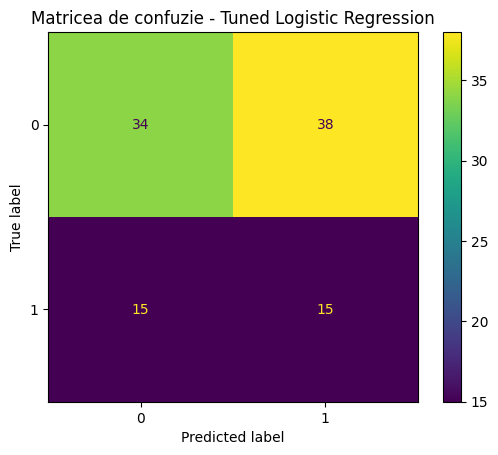

In [32]:
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matricea de confuzie - {best_model_name}")
plt.show()

Matricea de confuzie ajuta la intelegerea performantelor modelului.

Pentru aceasta problema, este important sa observam cate accidente reale au fost detectate corect si cate au fost ratate.


## 9.3 Curba ROC

Curba ROC arata capacitatea modelului de a separa cele doua clase.


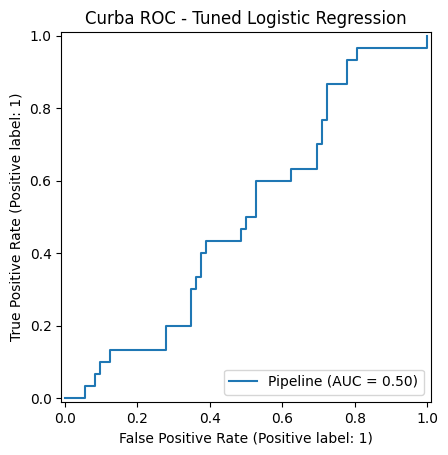

In [33]:
try:
    RocCurveDisplay.from_estimator(best_model, X_test, y_test)
    plt.title(f"Curba ROC - {best_model_name}")
    plt.show()
except Exception as e:
    print("Curba ROC nu a putut fi afisata:", e)

# 10. Curbele de invatare

Curbele de invatare sunt folosite pentru a analiza modul in care modelele invata pe masura ce creste dimensiunea setului de antrenare.

Acestea ajuta la identificarea:
- overfitting-ului
- underfitting-ului
- capacitatii de generalizare


In [34]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(7,4))
    plt.plot(train_sizes, train_mean, label="Train score")
    plt.plot(train_sizes, val_mean, label="Validation score")
    plt.xlabel("Training size")
    plt.ylabel("F1 score")
    plt.title(title)
    plt.legend()
    plt.show()

## 10.1 Curbele de invatare pentru top 5 modele optimizate

Afisam curbele de invatare pentru modelele optimizate.

Daca scorul de antrenare este mult mai mare decat scorul de validare, modelul poate avea overfitting.

Daca ambele scoruri sunt mici, modelul poate avea underfitting.

Daca cele doua scoruri sunt apropiate, modelul generalizeaza mai bine.


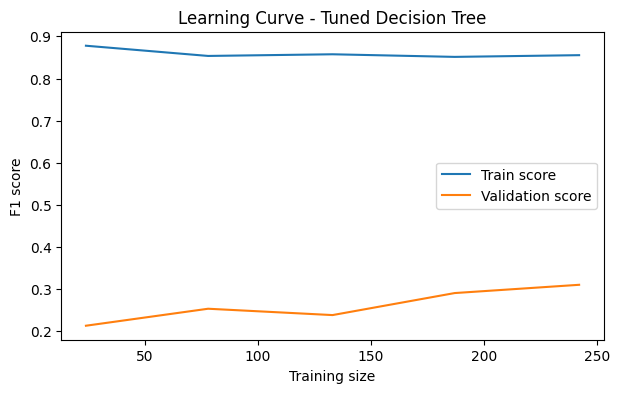

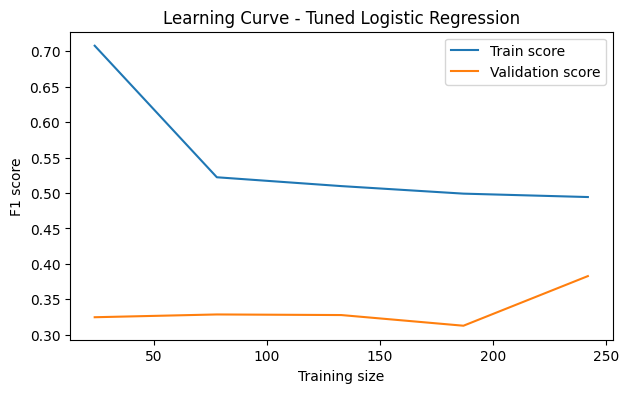

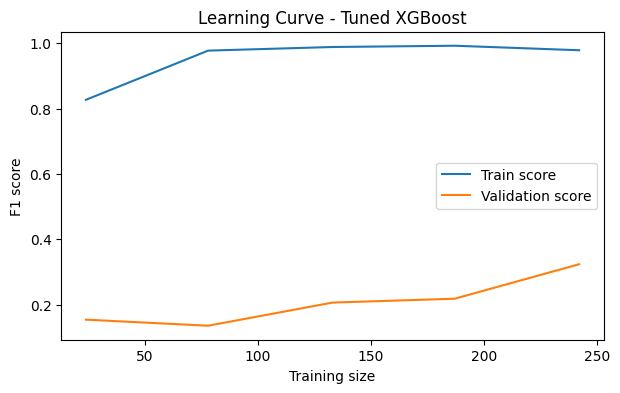

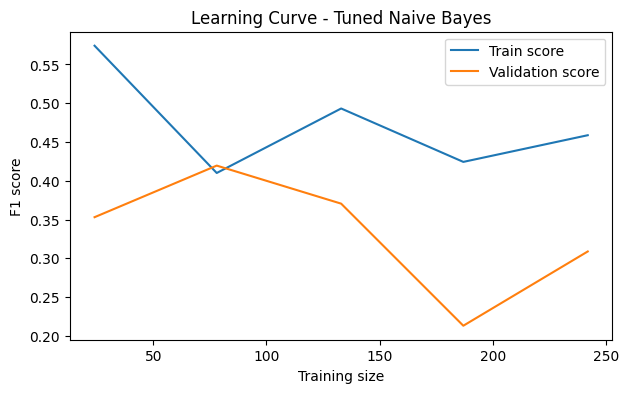

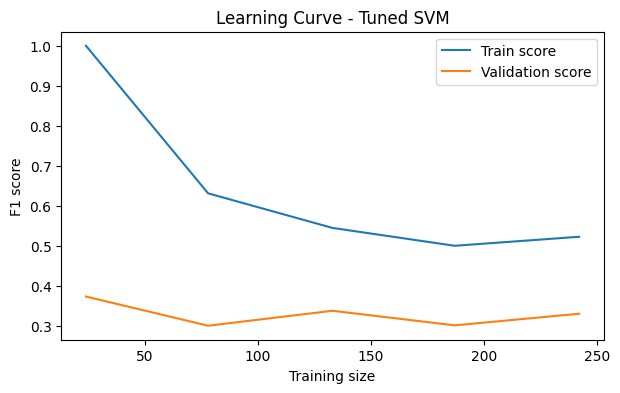

In [35]:
for name, model in tuned_models.items():
    plot_learning_curve(model, X_train, y_train, f"Learning Curve - {name}")

Curbele de invatare permit observarea comportamentului modelelor.

Un model stabil trebuie sa aiba scoruri apropiate intre antrenare si validare.

Daca exista un gap mare, atunci modelul poate invata prea mult detaliile setului de antrenare si poate generaliza mai slab.


# 11. Explicabilitatea modelelor folosind SHAP

SHAP este folosit pentru a interpreta modul in care modelele fac predictii.

Aceasta metoda arata contributia fiecarei caracteristici la predictia finala.

Vom analiza explicabilitatea pentru primele 3 modele optimizate, folosind un subset de date pentru a reduce timpul de calcul.


In [36]:
import shap

## 11.1 Pregatirea datelor pentru SHAP

Pentru SHAP folosim un subset al datelor, deoarece metoda poate fi costisitoare computational.


In [37]:
X_background = X_train.sample(min(50, len(X_train)), random_state=42)
X_shap = X_test.sample(min(30, len(X_test)), random_state=42)

## 11.2 SHAP summary plot si bar plot pentru primele 3 modele

Summary plot-ul arata impactul caracteristicilor asupra predictiilor.

Bar plot-ul arata importanta medie a caracteristicilor.


SHAP pentru modelul: Tuned Logistic Regression


  0%|          | 0/30 [00:00<?, ?it/s]

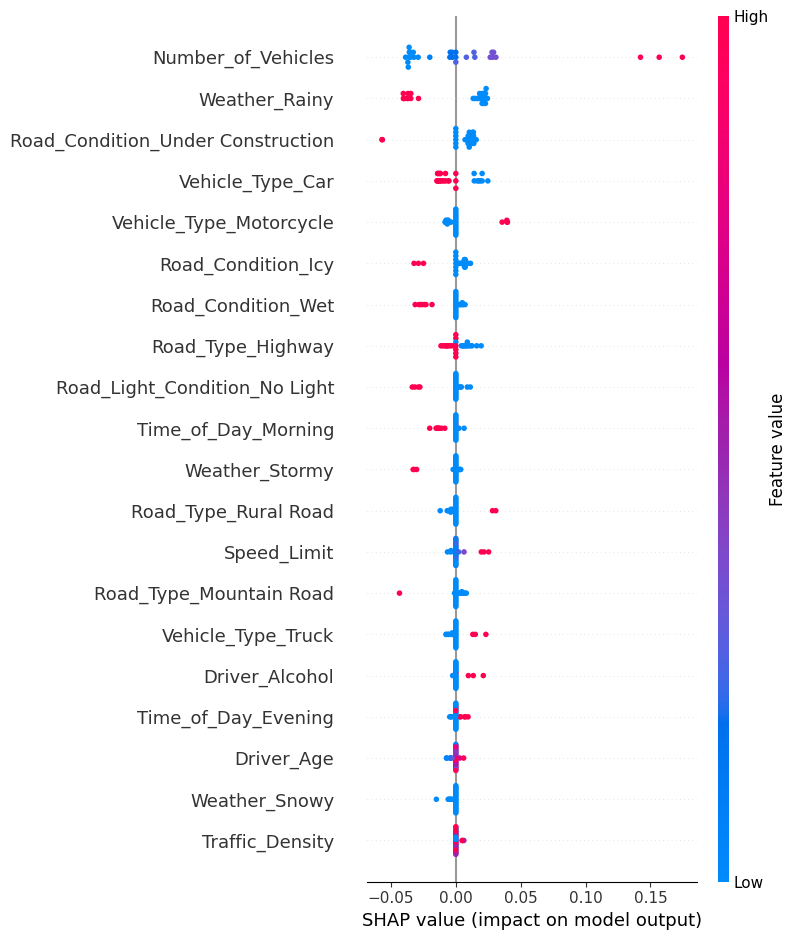

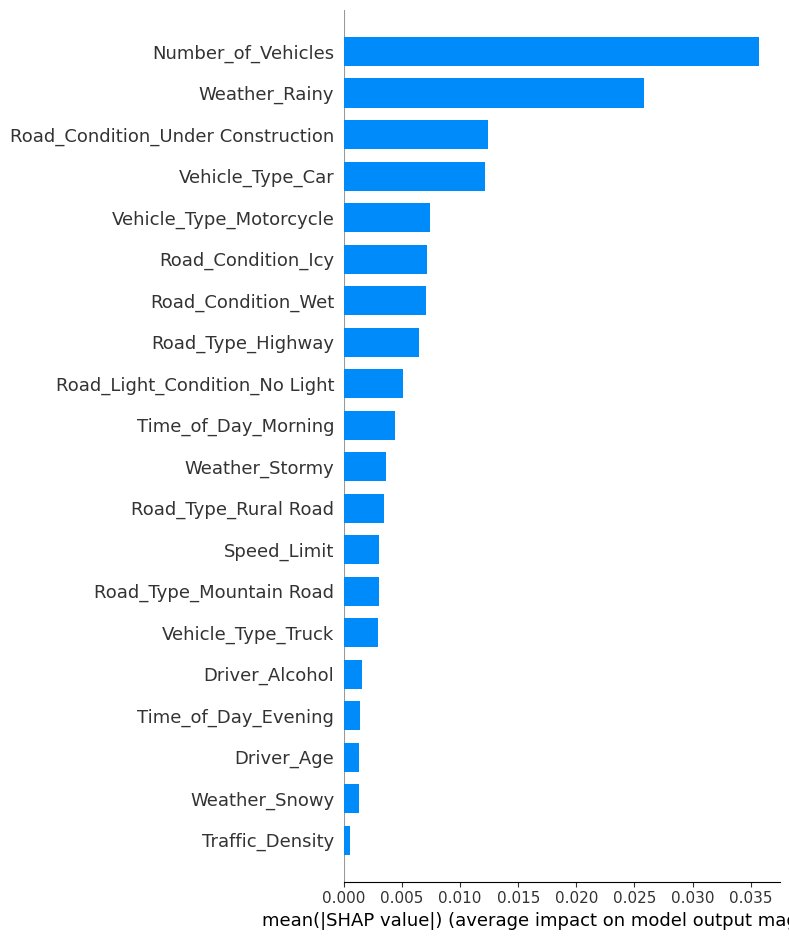

SHAP pentru modelul: Tuned XGBoost
Provided model function fails when applied to the provided data set.
SHAP nu a functionat pentru Tuned XGBoost: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Traffic_Density: object, Speed_Limit: object, Number_of_Vehicles: object, Driver_Alcohol: object, Driver_Age: object, Driver_Experience: object, Weather_Foggy: object, Weather_Rainy: object, Weather_Snowy: object, Weather_Stormy: object, Road_Type_Highway: object, Road_Type_Mountain Road: object, Road_Type_Rural Road: object, Time_of_Day_Evening: object, Time_of_Day_Morning: object, Time_of_Day_Night: object, Road_Condition_Icy: object, Road_Condition_Under Construction: object, Road_Condition_Wet: object, Vehicle_Type_Car: object, Vehicle_Type_Motorcycle: object, Vehicle_Type_Truck: object, Road_Light_Condition_Daylight: object, Road_Light_Condition_

  0%|          | 0/30 [00:00<?, ?it/s]

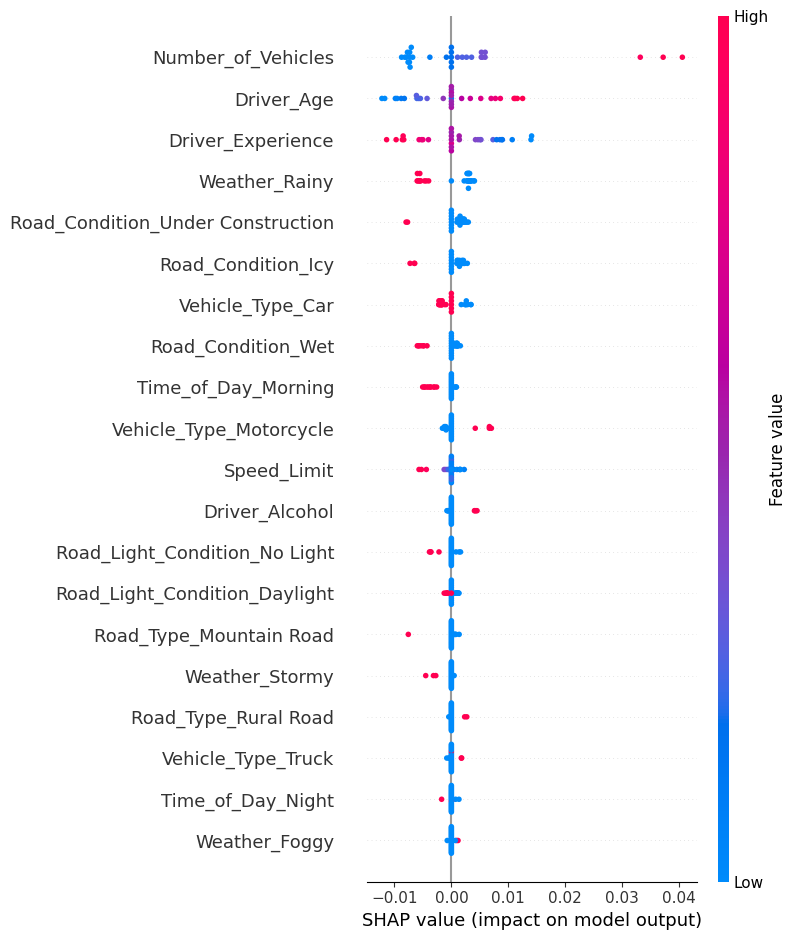

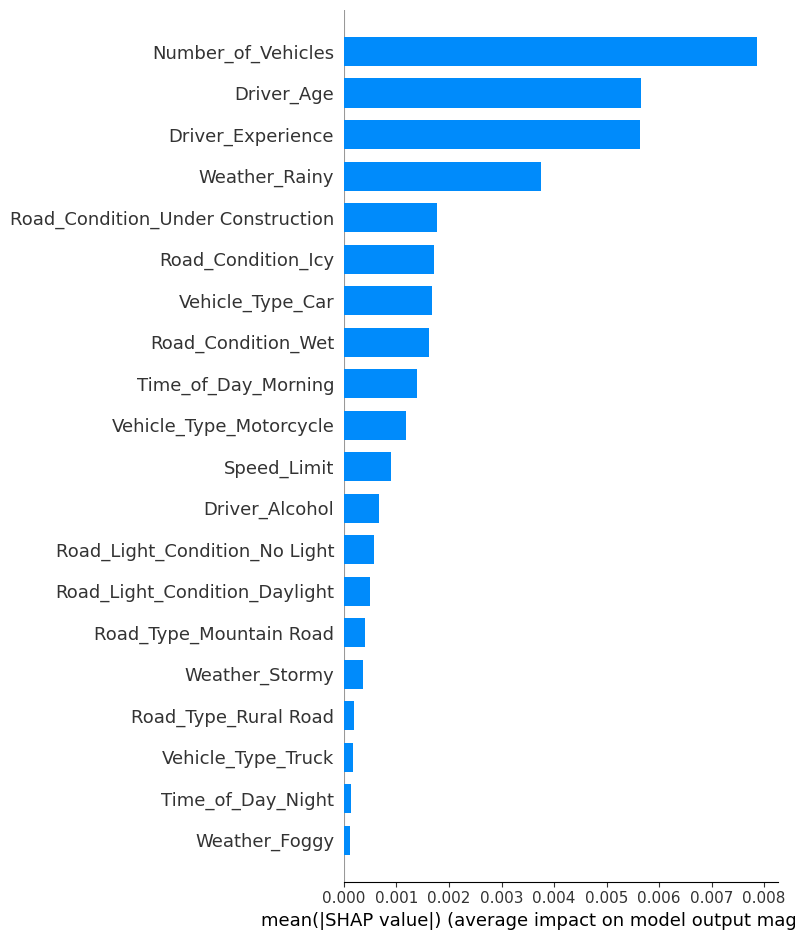

In [38]:
top3_tuned_names = tuned_results_df.sort_values(by="F1", ascending=False).head(3)["Model"].tolist()

shap_results = {}

for name in top3_tuned_names:
    print(f"SHAP pentru modelul: {name}")
    model = tuned_models[name]

    try:
        explainer = shap.KernelExplainer(
            lambda data: model.predict_proba(pd.DataFrame(data, columns=X_train.columns))[:, 1],
            X_background
        )
        shap_values = explainer.shap_values(X_shap, nsamples=100)

        shap_results[name] = (explainer, shap_values)

        shap.summary_plot(shap_values, X_shap, show=True)
        shap.summary_plot(shap_values, X_shap, plot_type="bar", show=True)

    except Exception as e:
        print(f"SHAP nu a functionat pentru {name}:", e)

## 11.3 Waterfall plot pentru modelul final

Waterfall plot-ul explica o singura predictie si arata ce variabile au crescut sau au scazut probabilitatea de accident.


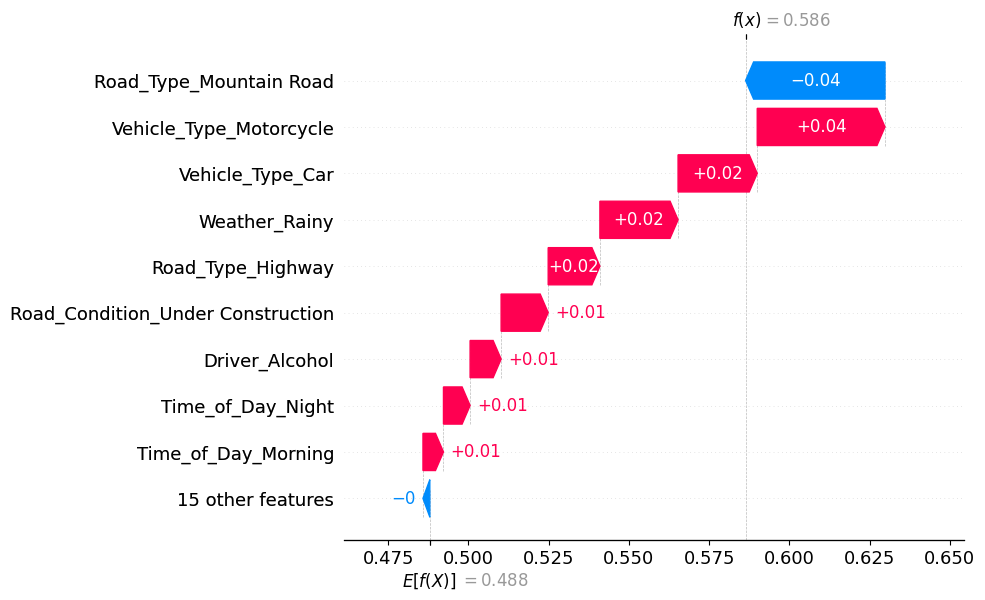

In [39]:
try:
    explainer, shap_values = shap_results[best_model_name]

    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = np.array(expected_value).flatten()[-1]

    shap_single = np.array(shap_values[0]).flatten()

    shap.plots._waterfall.waterfall_legacy(
        expected_value,
        shap_single,
        feature_names=X_train.columns
    )
except Exception as e:
    print("Waterfall plot nu a functionat automat:", e)

## 11.4 SHAP scatter plots

Scatter plot-urile SHAP arata modul in care valorile unor caracteristici influenteaza predictia.

Alegem automat cele mai importante 3 caracteristici pe baza valorilor SHAP medii.


Cele mai importante 3 caracteristici: ['Number_of_Vehicles', 'Weather_Rainy', 'Road_Condition_Under Construction']


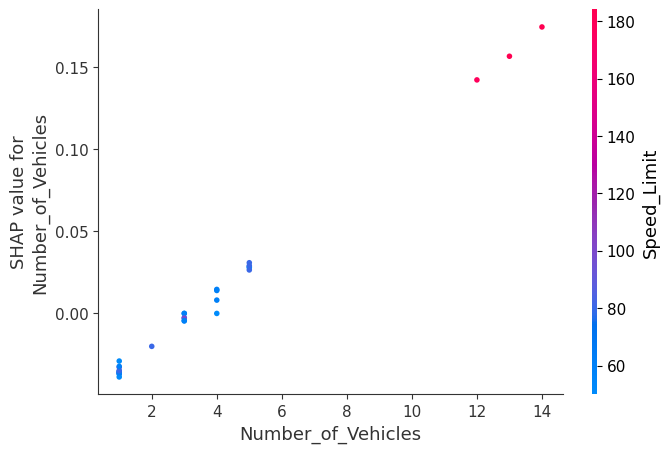

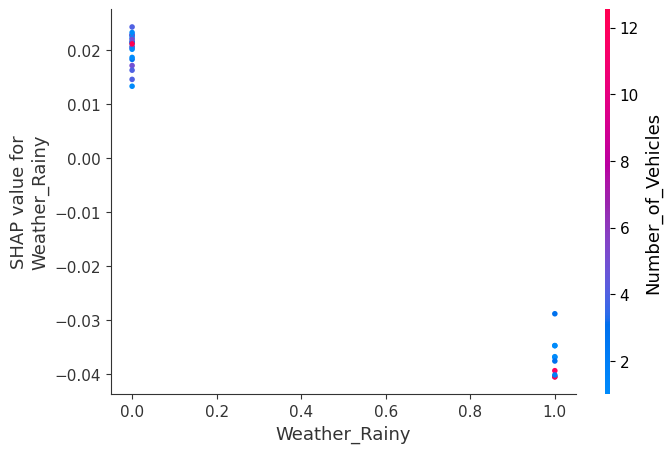

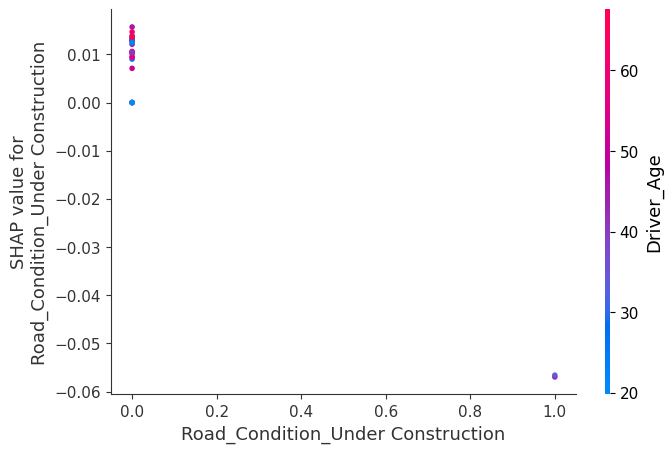

In [40]:
try:
    explainer, shap_values = shap_results[best_model_name]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_feature_indices = np.argsort(mean_abs_shap)[-3:][::-1]
    top_features = X_train.columns[top_feature_indices]

    print("Cele mai importante 3 caracteristici:", list(top_features))

    for feature in top_features:
        shap.dependence_plot(feature, shap_values, X_shap)
except Exception as e:
    print("SHAP scatter plots nu au functionat automat:", e)

## 11.5 Interpretarea rezultatelor SHAP

Analiza SHAP arata care variabile influenteaza cel mai mult predictia accidentelor.

Caracteristicile aflate in partea de sus a summary plot-ului si a bar plot-ului sunt cele mai importante.

Valorile SHAP pozitive cresc probabilitatea prezisa de accident, iar valorile SHAP negative o scad.

Prin waterfall plot se poate observa pentru un exemplu concret ce caracteristici au contribuit cel mai mult la predictia finala.

Prin scatter plot se poate analiza daca valorile mari sau mici ale unei caracteristici tind sa creasca sau sa scada riscul de accident.

Aceasta etapa este importanta deoarece arata ca modelul nu functioneaza doar ca o cutie neagra, ci poate fi interpretat.


# 12. Concluzii finale

In acest notebook a fost analizata problema predictiei accidentelor rutiere.

Variabila tinta a fost `Accident`, iar scopul a fost construirea unor modele de clasificare capabile sa prezica daca are loc sau nu un accident.

Au fost parcurse urmatoarele etape:
1. definirea problemei
2. analiza exploratorie a datelor
3. preprocesarea datelor
4. antrenarea mai multor modele de clasificare
5. compararea modelelor folosind Accuracy, Precision, Recall, F1 si ROC-AUC
6. selectarea celor mai bune 5 modele
7. ajustarea hiperparametrilor folosind GridSearchCV
8. compararea modelelor optimizate
9. analiza matricei de confuzie si a curbei ROC
10. analiza curbelor de invatare
11. interpretarea modelelor folosind SHAP

In aceasta problema, F1-score si Recall sunt mai importante decat Accuracy, deoarece ne intereseaza in special detectarea accidentelor.

Modelele optimizate au fost comparate pentru a identifica cea mai buna varianta.

Prin SHAP, au fost analizate caracteristicile care influenteaza cel mai mult predictia, ceea ce ajuta la intelegerea comportamentului modelului.

In concluzie, clasificarea este potrivita pentru aceasta problema, deoarece permite estimarea probabilitatii producerii unui accident in functie de factorii disponibili in dataset.
